In [1]:
!pip install hstrat downstream iplotx teeplot phyloframe

In [2]:
import seaborn as sns
import pandas as pd
import typing
import teeplot.teeplot as tp
import phyloframe.legacy as pfl
import itertools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.path


In [3]:
!wget https://raw.githubusercontent.com/mmore500/hstrat-synthesis/refs/heads/main/pylib/track_ca.py
!wget https://raw.githubusercontent.com/mmore500/hstrat-synthesis/refs/heads/main/pylib/tree/_draw_scatter_tree.py

--2026-04-26 16:50:59--  https://raw.githubusercontent.com/mmore500/hstrat-synthesis/refs/heads/main/pylib/track_ca.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18325 (18K) [text/plain]
Saving to: ‘track_ca.py’

track_ca.py         100%[===================>]  17.90K  --.-KB/s    in 0s      

2026-04-26 16:50:59 (120 MB/s) - ‘track_ca.py’ saved [18325/18325]

--2026-04-26 16:50:59--  https://raw.githubusercontent.com/mmore500/hstrat-synthesis/refs/heads/main/pylib/tree/_draw_scatter_tree.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 20

In [4]:
!curl -L https://osf.io/download/5g3rz/ -o phylos.pkl

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 67.4M  100 67.4M    0     0  57.5M      0  0:00:01  0:00:01 --:--:--  160M


In [5]:
import pickle

with open("phylos.pkl", "rb") as f:
    phylos = pickle.load(f)

In [6]:
def add_position_cols(df: pd.DataFrame) -> None:
    rect_verts = [(700, 250), (290, 1480), (1600, 1850), (1950, 650)]
    df["on_border"] = (~matplotlib.path.Path(rect_verts).contains_points(
        np.vstack([df["row"].to_numpy(), df["col"].to_numpy()]).T
    ) & df["extant"]).astype(bool)
    df["in_middle"] = (df["extant"] & ~df["on_border"]).astype(bool)

In [7]:
for p in phylos:
    add_position_cols(p)
    if "origin_time" in p.columns:
        p["_origin_time"] = p["origin_time"]
        del p["origin_time"]

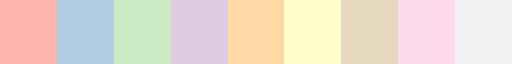

In [8]:
cmap = plt.get_cmap("Pastel1")
cmap

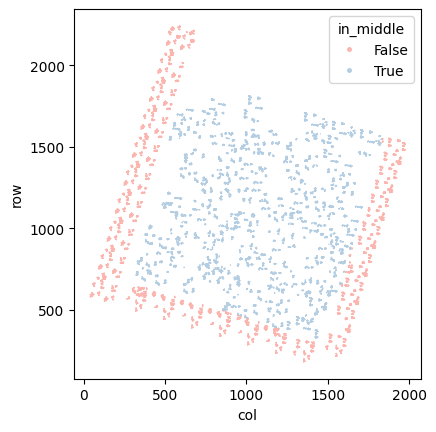

In [9]:
df = phylos[0]
ax = sns.scatterplot(data=phylos[0][phylos[0]["extant"] == True], x="col", y="row", s=0.5, linewidth=0, palette=cmap.colors, hue="in_middle")
ax.set_aspect("equal")
ax.legend(title="in_middle", markerscale=5)

In [10]:
import _draw_scatter_tree
from importlib import reload
_draw_scatter_tree = reload(_draw_scatter_tree)

def plot(df: pd.DataFrame, color_by: typing.Optional[str] = None, scatter_kws: dict = {}, tree_kws: dict = {}, **kwargs):
    with tp.teed(
        _draw_scatter_tree.draw_scatter_tree,
        df,
        hue=color_by,
        scatter_kws=dict(
            alpha=0.8,
            edgecolor="none",
            legend=True,
            **scatter_kws,
        ),
        scatter_shuffle=1,
        tree_kws=dict(
            edge=dict(
                color="gainsboro",
                linewidth=0.5,
            ),
            margins=-0.05,
            layout_angular=True,
            **tree_kws,
        ),
        teeplot_subdir=".",
        **kwargs,
    ) as teed:
        ...

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/alifedata_phyloinformatics_convert/_impl/phytrack_Systematcs.py:7: UserWarning: ImportWarning: phylotrackpy.Systematics import failed; inserting a no-op mock for Systematics. This is likely because phylotrackpy is not installed.
  warnings.warn(


teeplots/hue=position+viz=draw-scatter-tree+ext=.pdf
teeplots/hue=position+viz=draw-scatter-tree+ext=.png


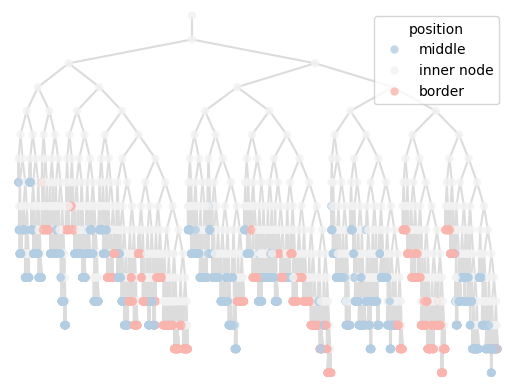

In [11]:
df = phylos[0].copy()
df["position"] = np.select([df["in_middle"], df["on_border"]], ["middle", "border"], "inner node")
plot(pfl.alifestd_downsample_tips_uniform_asexual(df, n_downsample=5_000), "position", scatter_kws={"palette": {
    "border": cmap.colors[0],
    "middle": cmap.colors[1],
    "inner node": cmap.colors[-1],
}})

teeplots/hue=on-border+viz=draw-scatter-tree+ext=.pdf
teeplots/hue=on-border+viz=draw-scatter-tree+ext=.png


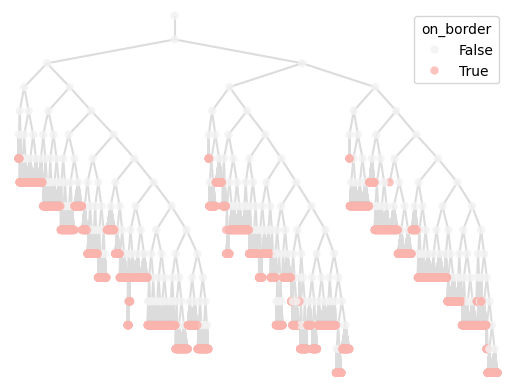

teeplots/hue=in-middle+viz=draw-scatter-tree+ext=.pdf
teeplots/hue=in-middle+viz=draw-scatter-tree+ext=.png


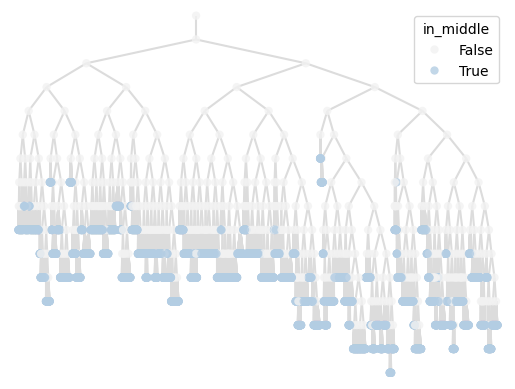

In [12]:
for i, key in enumerate(("on_border", "in_middle")):
    df = phylos[0].copy()
    df["extant"] = df[key]
    df = pfl.alifestd_prune_extinct_lineages_asexual(df)
    plot(pfl.alifestd_downsample_tips_uniform_asexual(df, n_downsample=5_000), key, scatter_kws={"palette": {
        True: cmap.colors[i],
        False: cmap.colors[-1]
    }})

In [13]:
for p in phylos:
    p["origin_time"] = p["_origin_time"]
    p.loc[0, "origin_time"] = 0

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/hue=on-border+viz=draw-scatter-tree+ext=.pdf, overwriting it
  warnings.warn(


teeplots/hue=on-border+viz=draw-scatter-tree+ext=.pdf


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/hue=on-border+viz=draw-scatter-tree+ext=.png, overwriting it
  warnings.warn(


teeplots/hue=on-border+viz=draw-scatter-tree+ext=.png


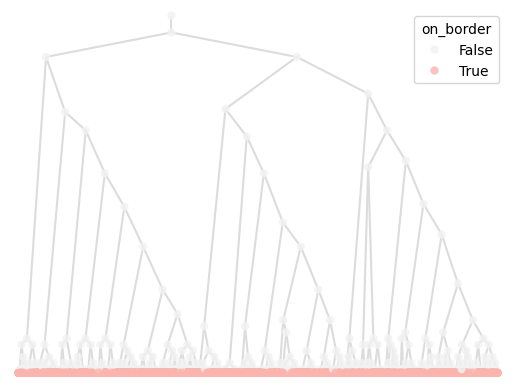

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/hue=in-middle+viz=draw-scatter-tree+ext=.pdf, overwriting it
  warnings.warn(


teeplots/hue=in-middle+viz=draw-scatter-tree+ext=.pdf


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/hue=in-middle+viz=draw-scatter-tree+ext=.png, overwriting it
  warnings.warn(


teeplots/hue=in-middle+viz=draw-scatter-tree+ext=.png


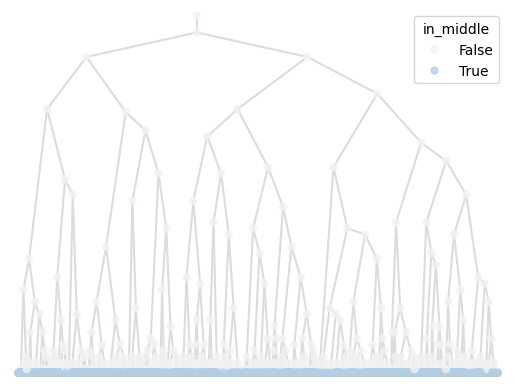

In [14]:
for i, key in enumerate(("on_border", "in_middle")):
    df = phylos[1].copy()
    df["extant"] = df[key]
    df = pfl.alifestd_prune_extinct_lineages_asexual(df)
    plot(pfl.alifestd_downsample_tips_uniform_asexual(df, n_downsample=5_000), key, scatter_kws={"palette": {
        True: cmap.colors[i],
        False: cmap.colors[-1]
    }})

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/hue=position+viz=draw-scatter-tree+ext=.pdf, overwriting it
  warnings.warn(


teeplots/hue=position+viz=draw-scatter-tree+ext=.pdf


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/hue=position+viz=draw-scatter-tree+ext=.png, overwriting it
  warnings.warn(


teeplots/hue=position+viz=draw-scatter-tree+ext=.png


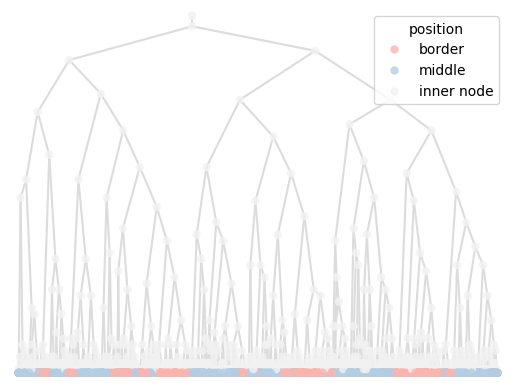

In [15]:
df = phylos[0].copy()
df["position"] = np.select([df["in_middle"], df["on_border"]], ["middle", "border"], "inner node")
plot(pfl.alifestd_downsample_tips_uniform_asexual(df, n_downsample=5_000), "position", scatter_kws={"palette": {
    "border": cmap.colors[0],
    "middle": cmap.colors[1],
    "inner node": cmap.colors[-1],
}})

teeplots/hue=on-border+size=colless-like-index-mdm+viz=draw-scatter-tree+ext=.pdf
teeplots/hue=on-border+size=colless-like-index-mdm+viz=draw-scatter-tree+ext=.png


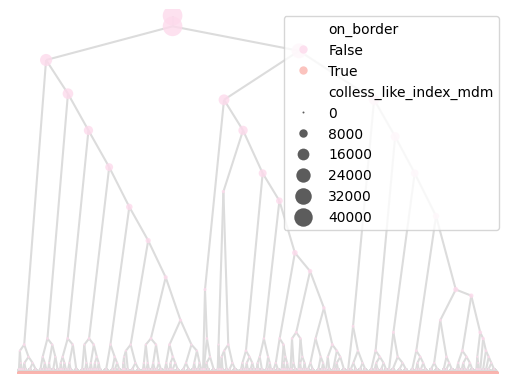

teeplots/hue=in-middle+size=colless-like-index-mdm+viz=draw-scatter-tree+ext=.pdf
teeplots/hue=in-middle+size=colless-like-index-mdm+viz=draw-scatter-tree+ext=.png


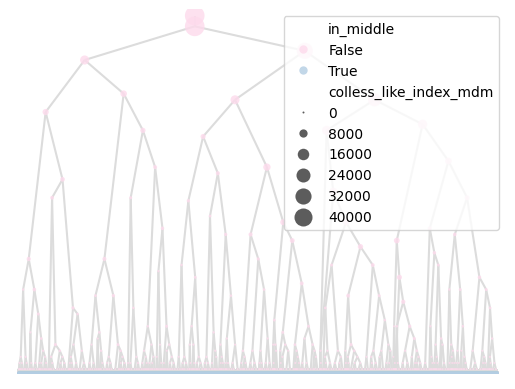

In [16]:
for i, key in enumerate(("on_border", "in_middle")):
    df = phylos[0].copy()
    df["extant"] = df[key]
    df = pfl.alifestd_prune_extinct_lineages_asexual(df)
    df = pfl.alifestd_collapse_unifurcations(df)
    df = pfl.alifestd_mark_colless_like_index_mdm_asexual(df)
    df = pfl.alifestd_mark_num_leaves_asexual(df)

    n = df["num_leaves"].to_numpy(dtype=np.float64)
    c = df["colless_like_index_mdm"].to_numpy(dtype=np.float64)

    plot(df, key, scatter_kws={
        "sizes": (2, 200),
        "palette": {
            True: cmap.colors[i],
            False: cmap.colors[-2]
        }
    }, collapse_unifurcations=False, size="colless_like_index_mdm")

In [17]:
focus_range = (2000, 12000)

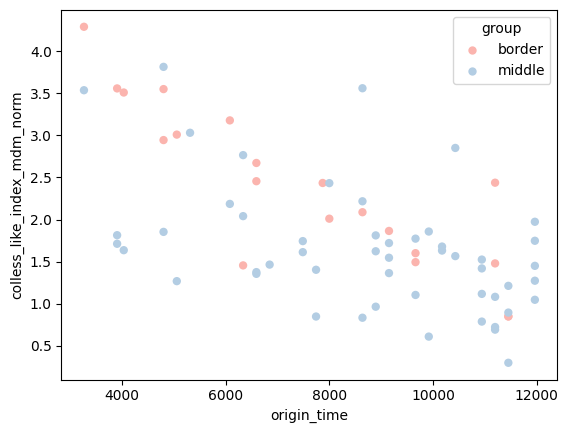

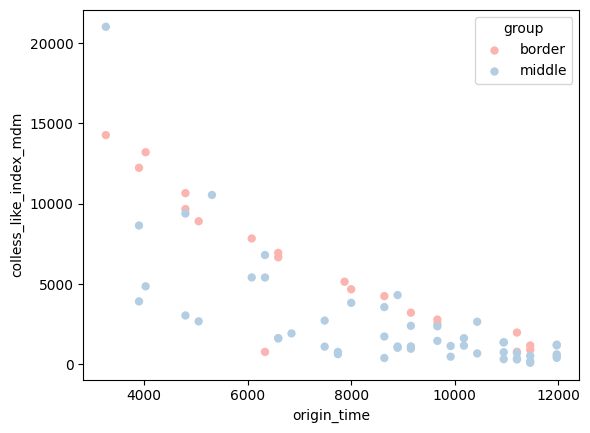

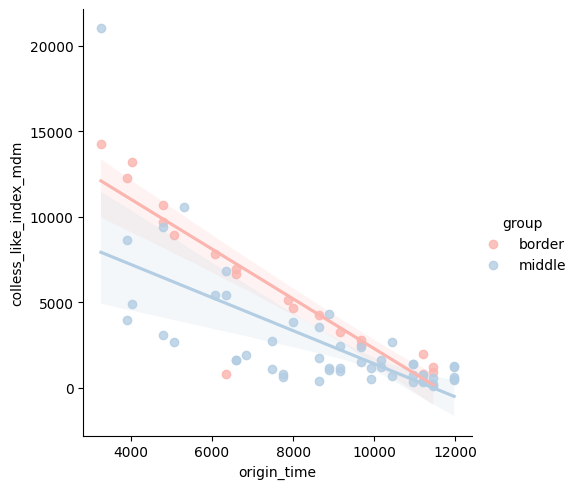

<Axes: xlabel='colless_like_index_mdm_norm', ylabel='group'>

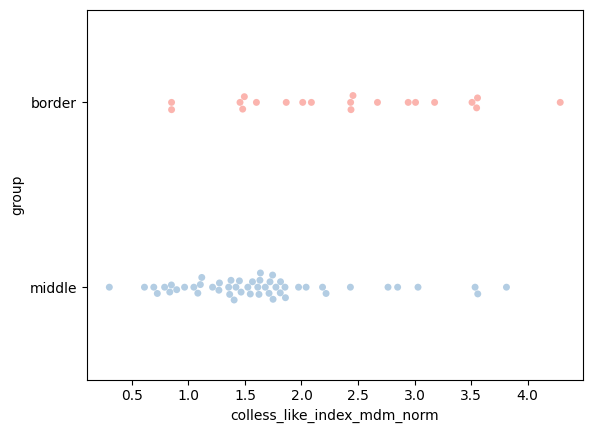

In [18]:
data = []

keys_of_interest = (
    "origin_time",
    "colless_like_index_mdm",
    "colless_like_index_mdm_norm"
)
for i, key in enumerate(("on_border", "in_middle")):
    df = phylos[1].copy()
    df["extant"] = df[key]
    df = pfl.alifestd_prune_extinct_lineages_asexual(df)
    df = pfl.alifestd_collapse_unifurcations(df)
    df = pfl.alifestd_mark_colless_like_index_mdm_asexual(df)
    df = pfl.alifestd_mark_num_leaves_asexual(df)

    n = df["num_leaves"].to_numpy(dtype=np.float64)
    c = df["colless_like_index_mdm"].to_numpy(dtype=np.float64)

    result = np.zeros_like(n)
    mask = n > 2
    # result[mask] = 2.0 * c[mask] / ((n[mask] - 1.0) * (n[mask] - 2.0))
    result[mask] = 2.0 * c[mask] / n[mask]

    df["colless_like_index_mdm_norm"] = result
    data.append(tuple(
        df[x][(focus_range[0] < df["origin_time"]) & (df["origin_time"] < focus_range[1])]
        for x in keys_of_interest
    ))

plot_df = pd.DataFrame({
    **{k: pd.concat([data[0][i], data[1][i]]) for i, k in enumerate(keys_of_interest)},
    "group": ["border"] * len(data[0][0]) + ["middle"] * len(data[1][0])
})

sns.scatterplot(
    data=plot_df,
    x="origin_time",
    y="colless_like_index_mdm_norm",
    hue="group",
    palette={
        "border": cmap.colors[0],
        "middle": cmap.colors[1],
    },
    linewidth=0,
)
plt.show()

sns.scatterplot(
    data=plot_df,
    x="origin_time",
    y="colless_like_index_mdm",
    hue="group",
    palette={
        "border": cmap.colors[0],
        "middle": cmap.colors[1],
    },
    linewidth=0,
)
plt.show()

sns.lmplot(
    data=plot_df,
    x="origin_time",
    y="colless_like_index_mdm",
    hue="group",
    palette={
        "border": cmap.colors[0],
        "middle": cmap.colors[1],
    },
)
plt.show()

sns.swarmplot(
    data=plot_df,
    x="colless_like_index_mdm_norm",
    y="group",
    hue="group",
    palette={
        "border": cmap.colors[0],
        "middle": cmap.colors[1],
    }
)

In [19]:
import scipy.stats

scipy.stats.mannwhitneyu(plot_df[plot_df["group"] == "border"]["colless_like_index_mdm_norm"],
                         plot_df[plot_df["group"] == "middle"]["colless_like_index_mdm_norm"])

MannwhitneyuResult(statistic=np.float64(750.0), pvalue=np.float64(0.0022025410660338664))

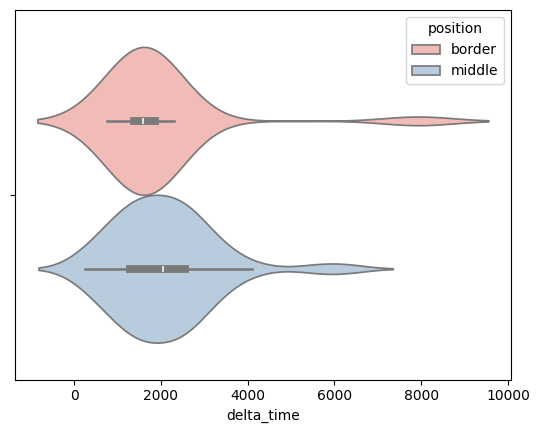

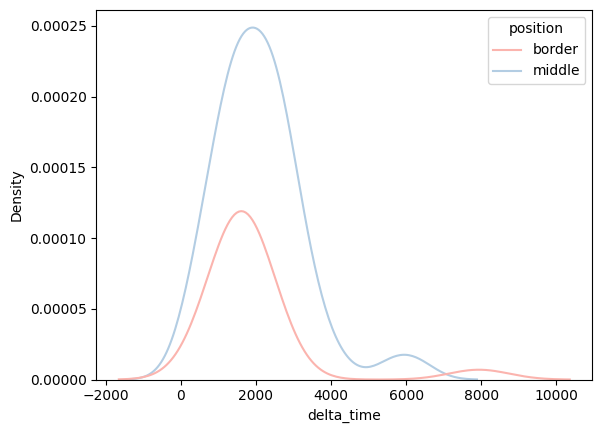

<Axes: xlabel='delta_time', ylabel='position'>

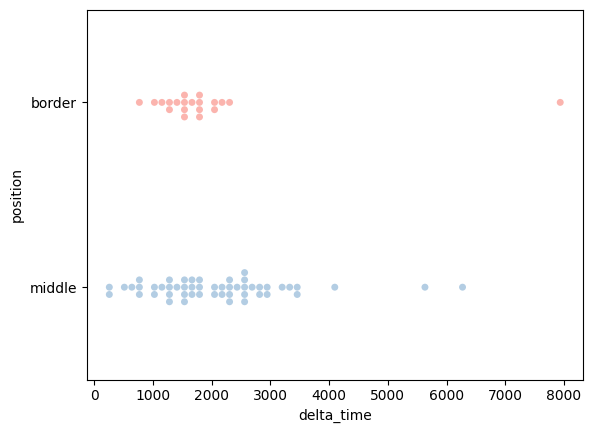

In [20]:
dfs = [
    phylos[1].assign(extant=phylos[1][key])
      .pipe(pfl.alifestd_prune_extinct_lineages_asexual)
      .pipe(pfl.alifestd_collapse_unifurcations)
      .pipe(pfl.alifestd_mark_origin_time_delta_asexual)
    for key in ("on_border", "in_middle")
]

delta_times = []
for df in dfs:
    delta_times.append(df["origin_time_delta"][(focus_range[0] < df["origin_time"]) & (df["origin_time"] < focus_range[1])])

df = pd.DataFrame({
    "delta_time": pd.concat(delta_times),
    "position": ["border"] * len(delta_times[0]) + ["middle"] * len(delta_times[1])
})

sns.violinplot(
    data=df,
    x="delta_time",
    hue="position",
    palette={
        "border": cmap.colors[0],
        "middle": cmap.colors[1],
    }
)
plt.show()
sns.kdeplot(
    data=df,
    x="delta_time",
    hue="position",
    palette={
        "border": cmap.colors[0],
        "middle": cmap.colors[1],
    }
)
plt.show()
sns.swarmplot(
    data=df,
    x="delta_time",
    y="position",
    hue="position",
    palette={
        "border": cmap.colors[0],
        "middle": cmap.colors[1],
    }
)